---
# Gaussian Mixture Models: EDA
### Daniel Ruiz, Emilio Delgado, Marc Dulcet, Marc Tomás, Gerard Pascual

En este Notebook se muestra el análisis exploratorio de datos de nuestro dataaset "Mall Customer Segmentation Data". Este dataset contiene información sobre clientes de un centro comercial, incluyendo su ID, género, edad, ingresos anuales y puntuación de gasto. Nuestro objetivo será entrenar un modelo Gaussian Mixture Models para clasificar a los clientes según los parámetros del dataset.


---
## 0. Importación de librerías y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

mall_df = pd.read_csv('Mall_Customers.csv')
mall_df.head()
mall_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


Podemos observar que el dataset cuenta con 5 variables:

- CustomerID: El identificador del cliente.
- Gender: El sexo del cliente.
- Age: La edad del cliente.
- Annual Income: Los ingresos anuales del cliente en miles de dólares.
- Spending Score: Por último, la puntuación de gasto del cliente en el centro comercial, un valor entre 1 y 100. Esta puntuación se le asigna al cliente según su comportamiento y gasto.


Este dataset tiene pocas variables (200 x 5), por lo que nos servirá para demostrar visualmente las virtudes de GMM y mostrar cómo difiere de otros algoritmos de clustering.

--- 
## 1. Seleción de variables y Análisis Univariante

Para este estudio, vamos a excluir CustomerID, ya que no nos aporta información, y Gender, una variable categórica.

Nuestras variables elegidas son Age, Income y Spending Score.

Vamos a calcular las métricas habituales, y observaremos sus distribuciones

Medidas de Tendencia Central:
Media:
 Age                       38.85
Annual Income (k$)        60.56
Spending Score (1-100)    50.20
dtype: float64

Mediana:
 Age                       36.0
Annual Income (k$)        61.5
Spending Score (1-100)    50.0
dtype: float64

Cuartiles:
Q1 (25%):
 Age                       28.75
Annual Income (k$)        41.50
Spending Score (1-100)    34.75
Name: 0.25, dtype: float64

Q2 (50% - Mediana):
 Age                       36.0
Annual Income (k$)        61.5
Spending Score (1-100)    50.0
Name: 0.5, dtype: float64

Q3 (75%):
 Age                       49.0
Annual Income (k$)        78.0
Spending Score (1-100)    73.0
Name: 0.75, dtype: float64


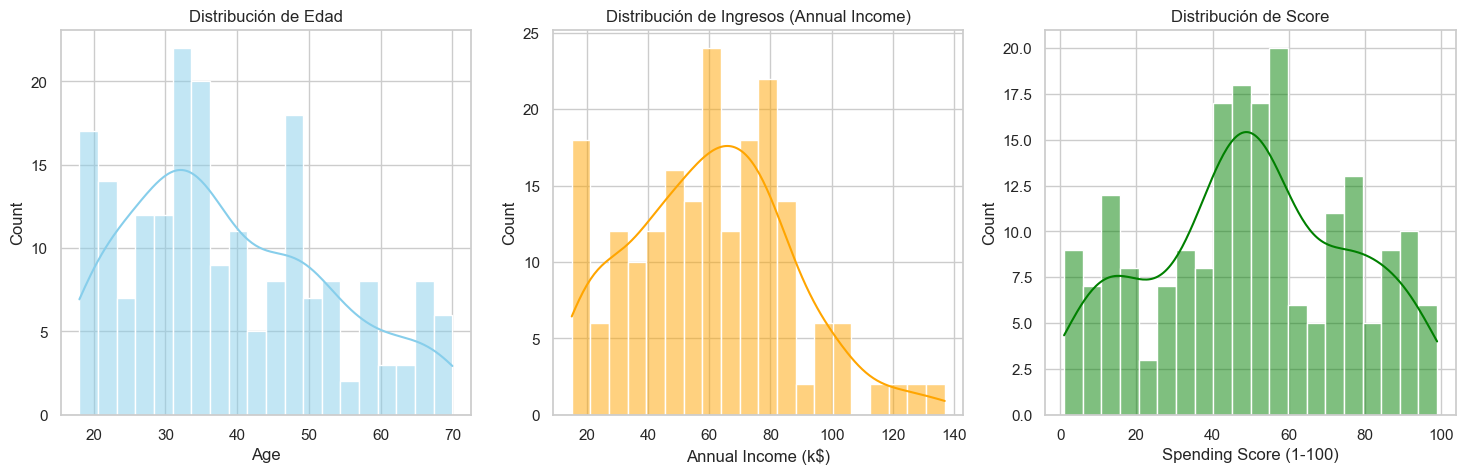

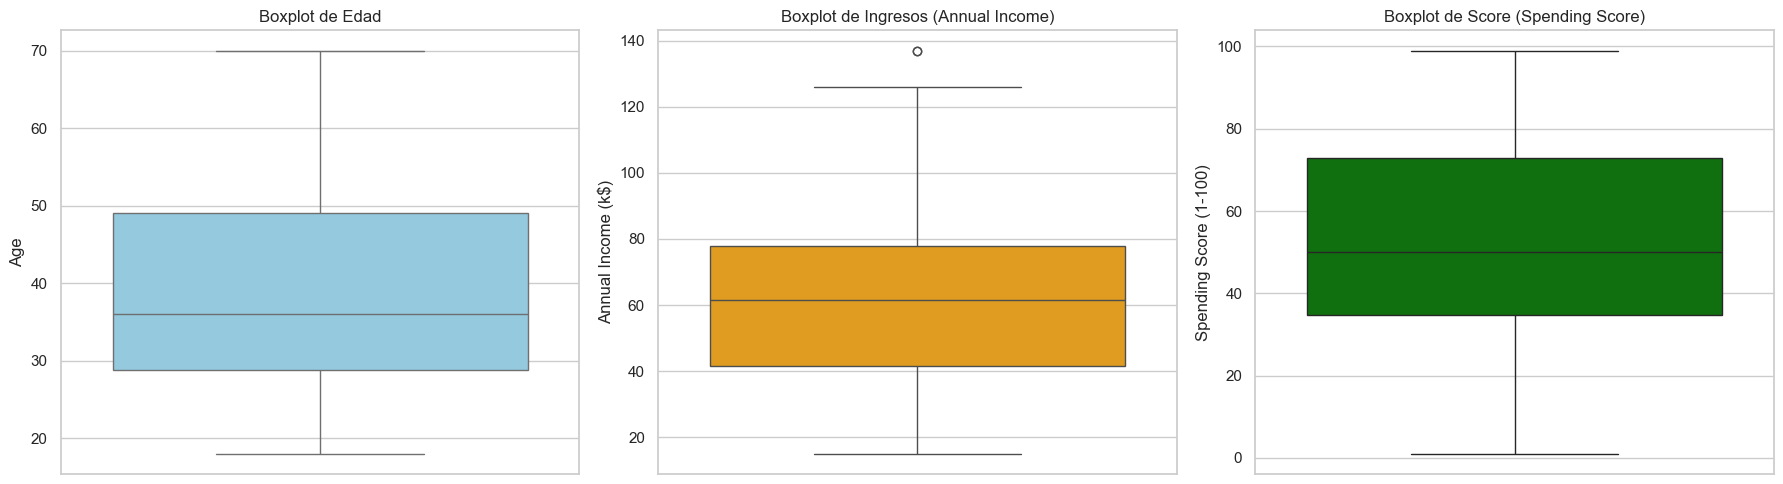

In [2]:
# Selección de variables numéricas de interés
X_raw = mall_df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

#Medidas de tendencia central
print("Medidas de Tendencia Central:")
print("Media:\n", X_raw.mean())
print("\nMediana:\n", X_raw.median())  

# Cuartiles
print("\nCuartiles:")
print("Q1 (25%):\n", X_raw.quantile(0.25))
print("\nQ2 (50% - Mediana):\n", X_raw.quantile(0.50))
print("\nQ3 (75%):\n", X_raw.quantile(0.75))


fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# Distribución de Edad
sns.histplot(mall_df['Age'], kde=True, ax=axes[0], color='skyblue', bins=20)
axes[0].set_title('Distribución de Edad')

# Distribución de Ingresos
sns.histplot(mall_df['Annual Income (k$)'], kde=True, ax=axes[1], color='orange', bins=20)
axes[1].set_title('Distribución de Ingresos (Annual Income)')

# Distribución de Score (Spending Score)
sns.histplot(mall_df['Spending Score (1-100)'], kde=True, ax=axes[2], color='green', bins=20)
axes[2].set_title('Distribución de Score')

#Boxplots para detectar outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(y=mall_df['Age'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot de Edad')
sns.boxplot(y=mall_df['Annual Income (k$)'], ax=axes[1], color='orange')
axes[1].set_title('Boxplot de Ingresos (Annual Income)')
sns.boxplot(y=mall_df['Spending Score (1-100)'], ax=axes[2], color='green')
axes[2].set_title('Boxplot de Score (Spending Score)')

#

plt.tight_layout()
plt.show()

Respecto a las medidas de tendencia central, tenemos las siguientes observaciones:
- La media de edad de los clientes del centro comercial es de casi 39 años, con unos ingresos anuales de 60500 dólares anuales, y un Score de 50.
- Los boxplots muestran, para la edad, una distribución que comporta desde una edad anterior a los 30 años hasta casi los 50, con la media localizándose más cercana al primer cuartil (36 años). Para los ingresos anuales, se comportan entre los 41500 y los 78000 dólares anuales. Por último, para el Score, se les ha asignado una puntuación a los clientes entre 34,75 y 73. No hay clientes con un Score perfecto todavía.

Como podemos observar, las variables no forman una campana perfecta. Tiene secciones cada una con su moda, lo que puede indicar grupos subyacentes. Por la parte de Income, se puede observar una asimetría positiva, donde los principales outliers son gente de altos ingresos. En el boxplot podemos observar que se tratan de outliers

GMM podrá manejar esta asimetría al asignar varianzas diferentes.

---
## 2. Análisis Bivariante

En este apartado vamos a estudiar la relación entre las variables seleccionadas, con el objetivo de estudiar cómo están distribuidos los clientes en el espacio de puntos. Vamos a representar mediante un scatterplot, los ingresos de los clientes en función de su Score.

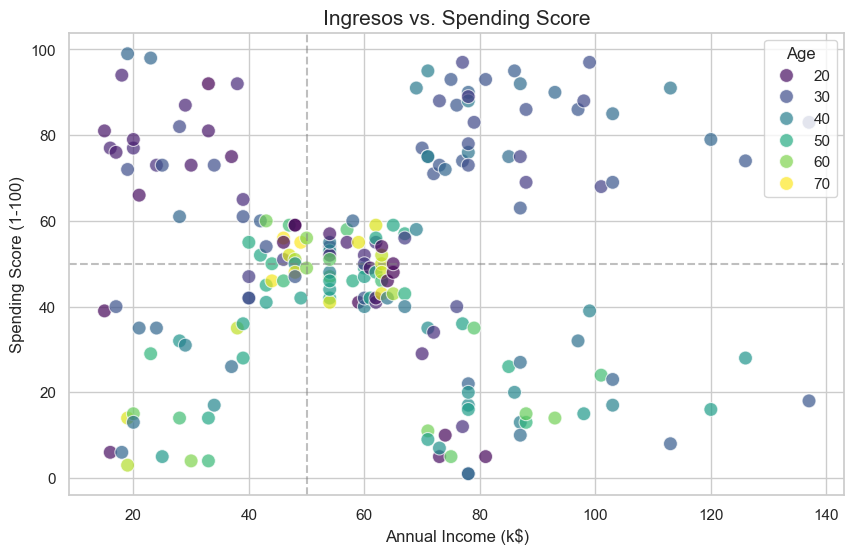

In [3]:
# Gráfico de dispersión: Ingresos vs Score
plt.figure(figsize=(10, 6))
sns.scatterplot(data=mall_df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Age', palette='viridis', s=100, alpha=0.7)

plt.title('Ingresos vs. Spending Score', fontsize=15)
plt.axhline(50, linestyle='--', color='gray', alpha=0.5) # Línea guía visual
plt.axvline(50, linestyle='--', color='gray', alpha=0.5) # Línea guía visual
plt.show()

En el espacio queda claro, se intuyen 5 grupos de clientes potenciales:
- Clientes con bajos ingresos y bajo Score.
- Clientes con bajos ingresos y alto Score.
- Clientes con ingresos medios y Score medio.
- Clientes con ingresos altos y Score bajo.
- Clientes con ingresos altos y Score alto.

No todos tienen una forma perfecta: Los 2 últimos grupos están bastante alargados hacia la derecha. Veremos si GMM, gracias a que permite clústers con formas elípticas (gracias a la matriz de covarianza), logra capturarlos.

Respecto a otros algoritmos, K-Means por ejemplo asume que los clústers:
- Son esféricos
- De igual tamaño

---
## 3. Análisis de densidad

En este apartado, mediante un mapa de calor, vamos a visualizar la probabilidad de encontrar un cliente en una cierta zona. Al final, GMM es un algoritmo probabilístico.

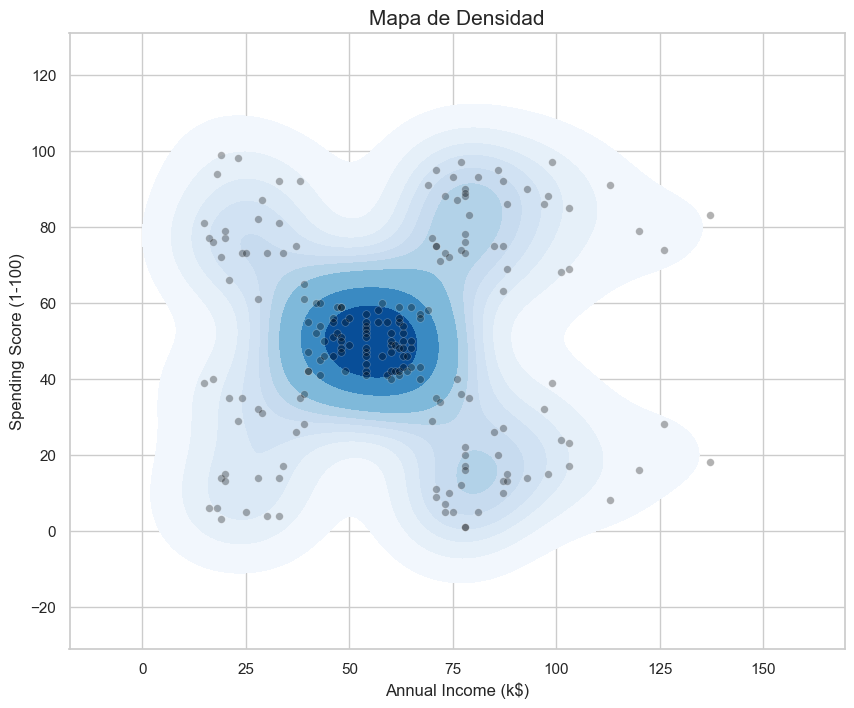

In [4]:
plt.figure(figsize=(10, 8))

# KDE Plot (Mapa de calor de densidad)
sns.kdeplot(data=mall_df, x='Annual Income (k$)', y='Spending Score (1-100)', fill=True, cmap="Blues", thresh=0.05)
sns.scatterplot(data=mall_df, x='Annual Income (k$)', y='Spending Score (1-100)', color='black', s=30, alpha=0.3)

plt.title('Mapa de Densidad', fontsize=15)
plt.show()

Gracias al mapa de calor, podemos observar islas de probabilidad. GMM intentará ajustar una campana de Gauss tridimensional sobre cada una de estas islas. Cuanto más oscura la zona, representa que hay mucha incertidumbre, lo que nos dará varias probabilidades de pertenecer a más de un clúster. Por ejemplo, 60% A, 30% B, 10% C.

---
## 4. Procesamiento final

Por último, vamos a dejar los datos listos para su utilización en el entrenamiento del modelo GMM. Como está basado en la varianza, es muy sensible a la escala. Por lo tanto, debemos escalar los datos para que estén numerados entre los mismos valores (0-100). Como el modelo es Gaussiano, vamos a estandarizar los datos para que tengan media 0 y desviación estándar 1.

In [5]:
# Estandarización (Z-score normalization)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns)

print("Datos listos para GMM (Media=0, Desviación=1):")
display(X_scaled.head())

Datos listos para GMM (Media=0, Desviación=1):


,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


--- 
## 5. CSV Estandarizado
Para poder utilizar el dataset en la siguiente fase, vamos a guardar nuestros datos en un CSV.

In [6]:
output_file = './Mall_Customers_Standardized.csv'

# Guardamos el DataFrame escalado (X_scaled)
X_scaled.to_csv(output_file, index=False)

print(f"¡Éxito! El dataset estandarizado se ha guardado como '{output_file}'")

# --- Verificación (Opcional) ---
# Leemos el archivo recién creado para asegurarnos de que todo está bien
df_check = pd.read_csv(output_file)
print("\nVerificación de las primeras 5 filas del archivo guardado:")
display(df_check.head())

# Comprobamos que la media sea cercana a 0 y desviación cercana a 1 (propiedad del escalado)
print("\nEstadísticas del archivo guardado (Media ~0, Std ~1):")
display(df_check.describe().round(2))

¡Éxito! El dataset estandarizado se ha guardado como './Mall_Customers_Standardized.csv'

Verificación de las primeras 5 filas del archivo guardado:


,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980



Estadísticas del archivo guardado (Media ~0, Std ~1):


,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-1.50,-1.74,-1.91
25%,-0.72,-0.73,-0.60
50%,-0.20,0.04,-0.01
75%,0.73,0.67,0.89
max,2.24,2.92,1.89


---
## 6. Conclusiones

El Análisis Exploratorio de Datos del dataset 'Mall Customers' confirma su idoneidad para Gaussian Mixture Models por tres razones:

- Multimodalidad: Las variables principales (especialmente Spending Score) no siguen una distribución normal única, sino una mezcla de varias, lo cual es la premisa básica de GMM.

- Separación no lineal: Los grupos visuales en el plano Ingreso-Gasto sugieren estructuras que podrían beneficiarse de la flexibilidad de las matrices de covarianza de GMM, en lugar de la rigidez esférica de K-Means.

- Zonas de transición: Existen puntos ubicados entre los clusters densos donde la asignación rígida (Hard Clustering) sería arbitraria. GMM nos permitirá asignar una probabilidad de pertenencia (Soft Clustering) más realista para estos perfiles de clientes."